In [1]:
import pandas as pd
import io

# Dataset de 30 registros: Edad, Salario, Compra
data = """Edad,Salario,Compra
25,35000,No
32,48000,No
47,70000,Si
50,85000,Si
22,20000,No
18,15000,No
40,62000,Si
35,58000,Si
28,40000,No
43,75000,Si
24,30000,No
55,95000,Si
38,50000,No
31,42000,No
49,88000,Si
20,22000,No
36,55000,Si
42,72000,Si
27,38000,No
58,105000,Si
21,21000,No
45,80000,Si
33,46000,No
29,41000,No
52,92000,Si
26,34000,No
39,64000,Si
41,68000,Si
23,28000,No
46,82000,Si"""

# Cargar el dataset en un DataFrame de pandas
df = pd.read_csv(io.StringIO(data))

# Mostrar las primeras filas y estadísticas básicas
print("Primeras filas del dataset:")
print(df.head())
print("\nDistribución de compras (Si/No):")
print(df['Compra'].value_counts())

Primeras filas del dataset:
   Edad  Salario Compra
0    25    35000     No
1    32    48000     No
2    47    70000     Si
3    50    85000     Si
4    22    20000     No

Distribución de compras (Si/No):
Compra
No    15
Si    15
Name: count, dtype: int64


In [2]:
df['Compra'] = df['Compra'].str.replace('Si' , '1')

In [3]:
df['Compra'] = df['Compra'].str.replace('No' , '0')


In [8]:
#la columna compra sigue siendo objeto tipo texto, sol que ahora tiene los valores de 1 y 0, por eso debe convertirse a num+
df['Compra'] = df['Compra'].astype(int)

In [4]:
df.head()

,Edad,Salario,Compra
0,25,35000,0
1,32,48000,0
2,47,70000,1
3,50,85000,1
4,22,20000,0


In [6]:
#seleccion de variables
# Seleccionamos todas las filas (:) y todas las columnas excepto la última (:-1)
X = df.iloc[:, :-1].values

In [7]:
# Seleccionamos todas las filas (:) y solo la última columna (-1)
y = df.iloc[:, -1].values

In [11]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Edad     30 non-null     int64
 1   Salario  30 non-null     int64
 2   Compra   30 non-null     int64
dtypes: int64(3)
memory usage: 852.0 bytes
None


In [14]:
from sklearn.model_selection import train_test_split
# 2. División de datos (80% entrenamiento, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
from sklearn.preprocessing import StandardScaler
# 3. Escalar variables (Standardization)
# Es vital en modelos lineales para que el Salario no domine a la Edad por su magnitud
sc = StandardScaler()

X_train = sc.fit_transform(X_train)

X_test = sc.transform(X_test)

In [17]:
print(X_train[0])

[-1.15373949 -1.08475696]


In [20]:
from sklearn.linear_model import LogisticRegression
# 4. Entrenar el modelo

classifier = LogisticRegression(random_state=42)

classifier.fit(X_train, y_train)

LogisticRegression(random_state=42)

In [21]:
 # 5. Hacer predicciones con el conjunto de test

y_pred = classifier.predict(X_test)

In [23]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
# 6. Evaluar al modelo
print("--- Evaluación del Modelo ---")
print(f"Precisión (Accuracy): {accuracy_score(y_test, y_pred) * 100}%")
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred))
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))

--- Evaluación del Modelo ---
Precisión (Accuracy): 100.0%

Matriz de Confusión:
[[3 0]
 [0 3]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         3

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



In [24]:
# 7. Prueba con NUEVOS DATOS
# Ejemplo: Persona de 30 años con salario de 45,000
nueva_persona = [[30, 45000]]
nueva_persona_escalada = sc.transform(nueva_persona)
prediccion_final = classifier.predict(nueva_persona_escalada)

In [25]:
resultado = "Comprará" if prediccion_final[0] == 1 else "No comprará"
print(f"\n--- Prueba con nuevo cliente ---")
print(f"Datos: {nueva_persona[0]}")
print(f"Predicción: {resultado}")


--- Prueba con nuevo cliente ---
Datos: [30, 45000]
Predicción: No comprará


In [26]:
# Ver la probabilidad de cada clase para los datos de test
# La primera columna es probabilidad de "No", la segunda es de "Si"
probabilidades = classifier.predict_proba(X_test)

print("Probabilidades (No comprar | Comprar):")
print(probabilidades)

Probabilidades (No comprar | Comprar):
[[0.20761351 0.79238649]
 [0.97114922 0.02885078]
 [0.81399663 0.18600337]
 [0.15787438 0.84212562]
 [0.83743986 0.16256014]
 [0.12437118 0.87562882]]


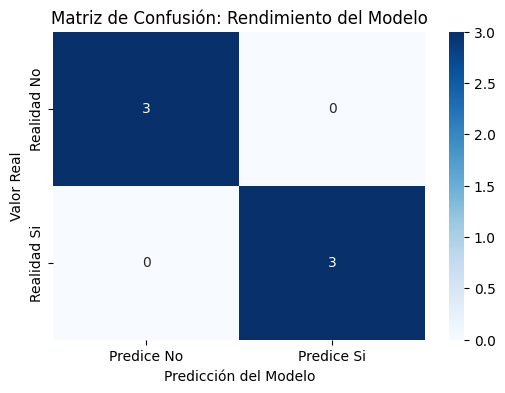

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predice No', 'Predice Si'],
            yticklabels=['Realidad No', 'Realidad Si'])
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión: Rendimiento del Modelo')
plt.show()

/tmp/ipykernel_13987/2464888764.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')


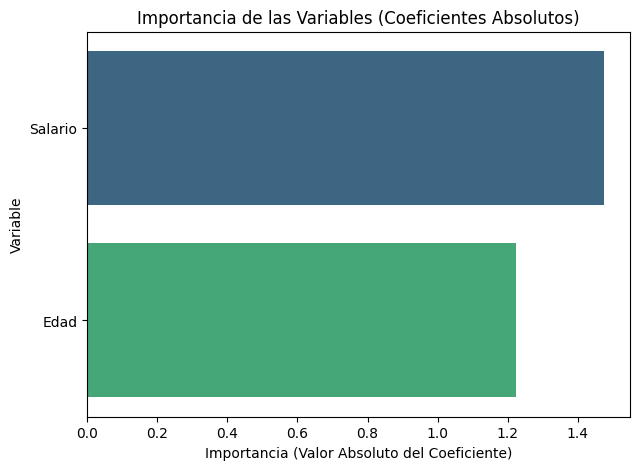

In [29]:
feature_importance = pd.DataFrame({
    'Feature': ['Edad', 'Salario'],
    'Importance': abs(classifier.coef_[0])
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(7, 5))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')
plt.title('Importancia de las Variables (Coeficientes Absolutos)')
plt.xlabel('Importancia (Valor Absoluto del Coeficiente)')
plt.ylabel('Variable')
plt.show()

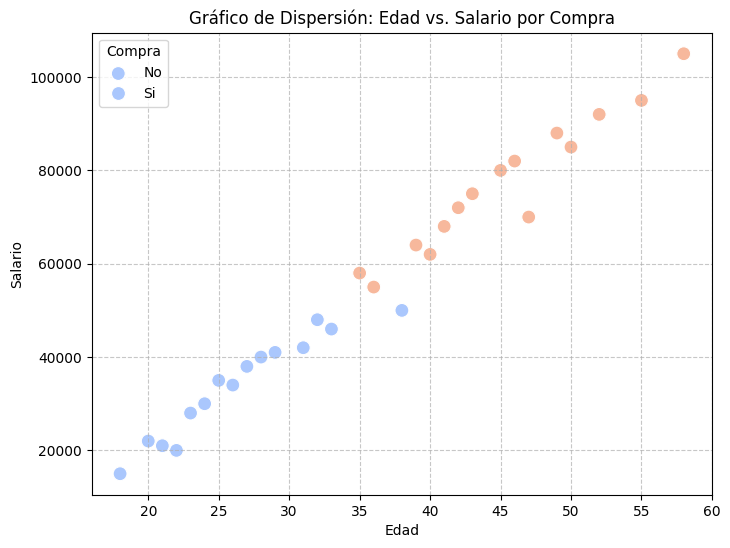

In [33]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Edad', y='Salario', hue='Compra', data=df, palette='coolwarm', s=100)
plt.title('Gráfico de Dispersión: Edad vs. Salario por Compra')
plt.xlabel('Edad')
plt.ylabel('Salario')
plt.legend(title='Compra', labels=['No', 'Si'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

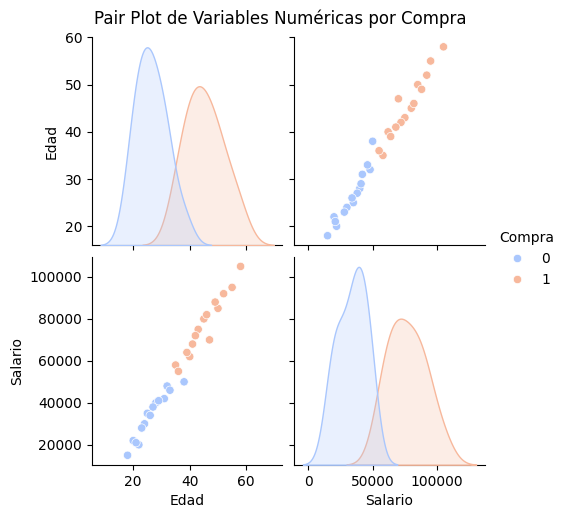

In [34]:
sns.pairplot(df, hue='Compra', palette='coolwarm')
plt.suptitle('Pair Plot de Variables Numéricas por Compra', y=1.02)
plt.show()

In [35]:
# Al final de tu evaluación
accuracy_v1 = accuracy_score(y_test, y_pred)
print(f"Precisión Modelo v1: {accuracy_v1}")

Precisión Modelo v1: 1.0
